<a href="https://colab.research.google.com/github/Rishabh-0408/Data-Science-and-AI/blob/main/Dimension%20Reduction/PCA/PCA_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Dataset**

In [4]:
from sklearn.datasets import load_digits

In [5]:
dataset = load_digits()
dataset

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [6]:
dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

**Importing library**

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.DataFrame(dataset.data, columns = dataset.feature_names)
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,pixel_1_2,pixel_1_3,pixel_1_4,pixel_1_5,pixel_1_6,pixel_1_7,pixel_2_0,pixel_2_1,pixel_2_2,pixel_2_3,pixel_2_4,pixel_2_5,pixel_2_6,pixel_2_7,pixel_3_0,pixel_3_1,pixel_3_2,pixel_3_3,pixel_3_4,pixel_3_5,pixel_3_6,pixel_3_7,pixel_4_0,pixel_4_1,pixel_4_2,pixel_4_3,pixel_4_4,pixel_4_5,pixel_4_6,pixel_4_7,pixel_5_0,pixel_5_1,pixel_5_2,pixel_5_3,pixel_5_4,pixel_5_5,pixel_5_6,pixel_5_7,pixel_6_0,pixel_6_1,pixel_6_2,pixel_6_3,pixel_6_4,pixel_6_5,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [9]:
df['Target'] = dataset.target

In [10]:
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,pixel_1_2,pixel_1_3,pixel_1_4,pixel_1_5,pixel_1_6,pixel_1_7,pixel_2_0,pixel_2_1,pixel_2_2,pixel_2_3,pixel_2_4,pixel_2_5,pixel_2_6,pixel_2_7,pixel_3_0,pixel_3_1,pixel_3_2,pixel_3_3,pixel_3_4,pixel_3_5,pixel_3_6,pixel_3_7,pixel_4_0,pixel_4_1,pixel_4_2,pixel_4_3,pixel_4_4,pixel_4_5,pixel_4_6,pixel_4_7,pixel_5_0,pixel_5_1,pixel_5_2,pixel_5_3,pixel_5_4,pixel_5_5,pixel_5_6,pixel_5_7,pixel_6_0,pixel_6_1,pixel_6_2,pixel_6_3,pixel_6_4,pixel_6_5,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,Target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


**Checking the shape/dimensions of the data**

In [11]:
df.shape

(1797, 65)

In [12]:
print(f"Rows : {df.shape[0]}, Columns : {df.shape[1]}")

Rows : 1797, Columns : 65


In [13]:
print(f"Target is: {dataset.target[0]}")
dataset.data[0]

Target is: 0


array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

**How we can use this data? what or How we can visualize the image?**

In [14]:
dataset.data[0] #its in one dimension data try to convert it into 2 or more dimensional data

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [15]:
dataset.data[0].reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

<Axes: >

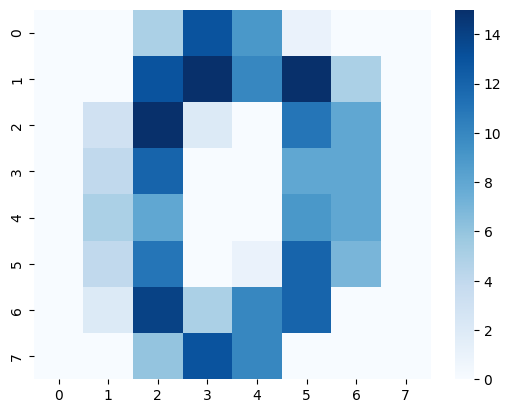

In [16]:
# Now using visualization to understand better
sns.heatmap(dataset.data[0].reshape(8,8), cmap = 'Blues')

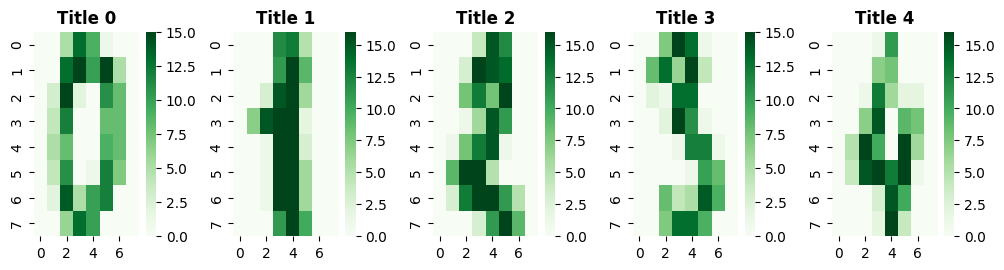

In [17]:
plt.figure(figsize = (10,5))
for i in range(5):
  plt.subplot(2, 5, i+1),
  sns.heatmap(dataset.images[i], cmap = 'Greens')
  plt.title(f"Title {i}", fontweight = "bold")

plt.tight_layout()
plt.show()

In [18]:
x = df.iloc[:, :-1] # Including all the columns except target
# All Independent Features
x
x.shape

(1797, 64)

In [19]:
y = dataset.target # label output
y
y.shape

(1797,)

**Let's Start Implementation of PCA**

In [20]:
# Step 1: We Standardize our Data
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
pd.DataFrame(x_scaled)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
0,0.0,-0.335016,-0.043081,0.274072,-0.664478,-0.844129,-0.409724,-0.125023,-0.059078,-0.624009,0.482974,0.759622,-0.058426,1.127721,0.879583,-0.130433,-0.044625,0.111443,0.895880,-0.860666,-1.149648,0.515472,1.905963,-0.114222,-0.03338,0.486489,0.469885,-1.499901,-1.614063,0.076398,1.541814,-0.047232,0.0,0.764656,0.052630,-1.447630,-1.736664,0.043616,1.439558,0.0,-0.061344,0.810554,0.630117,-1.122457,-1.066232,0.660965,0.818451,-0.088742,-0.035433,0.742119,1.150652,-0.868671,0.110130,0.537611,-0.757436,-0.209785,-0.023596,-0.299081,0.086719,0.208293,-0.366771,-1.146647,-0.505670,-0.196008
1,0.0,-0.335016,-1.094937,0.038648,0.268751,-0.138020,-0.409724,-0.125023,-0.059078,-0.624009,-1.915573,-0.246304,1.196450,0.136195,-0.514991,-0.130433,-0.044625,-0.727646,-1.213385,1.380308,1.441860,-0.291553,-0.548805,-0.114222,-0.03338,1.440185,0.954513,1.220586,0.987402,-0.945588,-0.628896,-0.047232,0.0,-0.672372,-1.054452,1.105570,0.960644,-0.978702,-0.822695,0.0,-0.061344,-0.531284,-0.899839,1.362175,1.330789,-0.392787,-0.798272,-0.088742,-0.035433,-0.403575,-1.153118,1.236394,1.242083,-0.457500,-0.757436,-0.209785,-0.023596,-0.299081,-1.089383,-0.249010,0.849632,0.548561,-0.505670,-0.196008
2,0.0,-0.335016,-1.094937,-1.844742,0.735366,1.097673,-0.409724,-0.125023,-0.059078,-0.624009,-1.362062,1.011104,0.987304,0.962467,-0.514991,-0.130433,-0.044625,-0.727646,-0.334525,1.035543,0.146106,1.322497,-0.548805,-0.114222,-0.03338,-0.785105,-1.307084,-0.479719,0.824811,0.587391,-0.628896,-0.047232,0.0,-0.384967,0.052630,0.626845,0.792062,-1.319475,-0.822695,0.0,-0.061344,2.487851,1.395095,1.362175,-0.427026,-1.446538,-0.798272,-0.088742,-0.035433,1.314966,0.973439,1.236394,1.242083,0.371759,0.259230,-0.209785,-0.023596,-0.299081,-1.089383,-2.078218,-0.164037,1.565686,1.695137,-0.196008
3,0.0,-0.335016,0.377661,0.744919,0.268751,-0.844129,-0.409724,-0.125023,-0.059078,1.879691,0.482974,-1.503711,0.987304,-0.690077,-0.514991,-0.130433,-0.044625,-0.168254,-1.564930,1.035543,0.955952,-1.259982,-0.548805,-0.114222,-0.03338,-0.785105,-1.145542,1.050555,0.174444,-1.115919,-0.628896,-0.047232,0.0,-0.672372,-1.212607,-1.288055,0.286317,0.554775,-0.539913,0.0,-0.061344,-0.531284,-1.052835,-1.122457,-1.066232,0.309714,1.049411,-0.088742,-0.035433,-0.403575,0.087374,-1.060040,-0.833165,0.869315,1.072563,-0.209785,-0.023596,-0.299081,0.282736,0.208293,0.241430,0.379040,-0.505670,-0.196008
4,0.0,-0.335016,-1.094937,-2.551014,-0.197863,-1.020657,-0.409724,-0.125023,-0.059078,-0.624009,-1.915573,-1.252229,-0.476718,-1.351095,-0.514991,-0.130433,-0.044625,-0.727646,-1.564930,1.035543,-0.177833,-0.937173,0.064887,-0.114222,-0.03338,-0.785105,-0.337828,1.050555,-1.614063,0.246729,1.541814,-0.047232,0.0,0.764656,1.317867,0.148120,-1.736664,1.236320,0.873995,0.0,-0.061344,0.810554,1.242100,1.362175,0.851385,1.363466,-0.567312,-0.088742,-0.035433,-0.403575,-1.330331,-1.251410,1.053424,0.205907,-0.757436,-0.209785,-0.023596,-0.299081,-1.089383,-2.306869,0.849632,-0.468564,-0.505670,-0.196008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,-0.335016,-0.253452,-0.432200,0.268751,0.038508,-0.409724,-0.125023,-0.059078,-0.311047,1.036485,0.508141,0.359866,1.292976,0.321753,-0.130433,-0.044625,0.391139,1.071653,-0.171136,-0.663741,1.322497,0.678579,-0.114222,-0.03338,-0.785105,0.469885,1.220586,0.987402,1.439046,0.727798,-0.047232,0.0,-0.672372,-1.212607,-0.809330,-1.062337,1.236320,1.439558,0.0,-0.061344,-0.531284,-1.052835,-1.122457,-1.226033,1.187841,0.356530,-0.088742,-0.035433,-0.403575,-0.444265,-0.485932,-0.455847,1.201019,0.055897,-0.209785,-0.023596,-0.299081,-0.697

**Calculating Covariance and Covariance Matrix**

In [22]:
# In Covariance
# Rows : Expected Variable
# Columnsa : Dependent Variable
# Our dataset donot follor this so we transpose it

pd.DataFrame(x_scaled.T)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,1757,1758,1759,1760,1761,1762,1763,1764,1765,1766,1767,1768,1769,1770,1771,1772,1773,1774,1775,1776,1777,1778,1779,1780,1781,1782,1783,1784,1785,1786,1787,1788,1789,1790,1791,1792,1793,1794,1795,1796
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,1.870202,-0.335016,5.178030,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,0.767593,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,1.870202,6.280639,-0.335016,2.972811,-0.335016,-0.335016,-0.335016,0.767593,...,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,0.767593,-0.335016,-0.335016,-0.335016,-0.335016,1.870202,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,2.972811,-0.335016,0.767593,-0.335016,-0.335016,0.767593,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016,-0.335016
2,-0.043081,-1.094937,-1.094937,0.377661,-1.094937,1.429517,-1.094937,0.377661,0.798404,1.219146,-0.884566,-1.094937,-0.043081,0.798404,-1.094937,1.429517,-1.094937,-0.884566,1.008775,0.167290,-0.463823,-1.094937,0.588032,0.588032,-1.094937,1.429517,-0.884566,-1.094937,1.008775,0.798404,1.008775,-0.674195,1.639888,1.639888,-1.094937,2.060631,0.167290,1.639888,0.377661,0.798404,...,-0.253452,-0.463823,0.377661,-0.884566,-0.884566,-0.674195,-0.043081,-1.094937,0.377661,0.588032,-1.094937,-0.043081,0.798404,1.008775,-1.094937,-0.043081,-0.674195,0.167290,0.167290,1.429517,-1.094937,-1.094937,-0.463823,1.850259,1.008775,1.008775,2.060631,-0.884566,1.008775,-0.253452,1.008775,-1.094937,0.588032,-0.043081,-1.094937,-0.253452,0.167290,-0.884566,-0.674195,1.008775
3,0.274072,0.038648,-1.844742,0.744919,-2.551014,-0.432200,0.038648,-0.903047,0.509495,0.038648,-0.667624,-2.786437,0.038648,0.744919,-0.903047,0.274072,-0.903047,-0.903047,-1.138471,0.509495,0.274072,-2.315590,0.980343,0.038648,-2.786437,-0.903047,0.274072,-0.903047,-0.196776,0.274072,0.509495,0.274072,0.980343,-1.609319,-1.609319,-0.903047,0.509495,-0.432200,-1.138471,0.980343,...,0.980343,0.274072,0.980343,0.038648,-0.432200,0.274072,0.038648,-2.080166,0.274072,0.038648,-2.315590,0.980343,0.038648,0.038648,-1.373895,0.509495,0.274072,0.038648,0.980343,0.980343,-2.315590,-2.551014,-0.432200,0.744919,0.980343,0.274072,0.274072,-0.432200,0.980343,0.509495,0.980343,-2.551014,0.980343,0.038648,-2.080166,-0.432200,0.980343,-0.196776,-0.432200,0.509495
4,-0.664478,0.268751,0.735366,0.268751,-0.197863,-2.764242,0.268751,0.268751,-0.897785,-2.764242,0.735366,0.502058,-2.530935,0.502058,0.735366,0.968673,0.735366,0.735366,0.268751,-1.831013,-0.197863,0.968673,-1.597706,0.735366,0.035444,-0.897785,0.502058,0.502058,-1.831013,-1.131092,-0.197863,-0.897785,0.968673,-0.897785,0.502058,-0.897785,-0.431170,-2.530935,0.268751,0.268751,...,0.968673,0.968673,-0.664478,-0.431170,0.968673,0.268751,0.268751,0.268751,0.968673,-0.197863,0.968673,-0.431170,0.502058,0.968673,0.035444,-0.197863,-0.431170,0.035444,0.968673,0.968673,0.502058,0.268751,0.968673,-1.364399,0.502058,-2.297628,-2.530935,0.5

In [23]:
# Now we Find Covariance
cov_matrix = np.cov(x_scaled.T)
pd.DataFrame(cov_matrix)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0,1.000557,0.556928,0.207929,-0.018771,0.060810,0.048415,-0.038948,0.032338,0.556682,0.224647,-0.109117,0.027923,-0.064019,-0.029990,-0.043722,-0.005112,0.213705,-0.113644,-0.105941,0.096307,-0.170165,-0.131403,-0.038288,-0.011189,-0.085959,-0.146465,0.073021,0.041106,-0.206433,-0.150838,-0.015832,0.0,-0.168389,-0.178587,0.044164,-0.059892,-0.235907,-0.173342,0.0,-0.020563,-0.124336,-0.143079,0.024256,-0.054747,-0.163363,-0.086514,-0.025750,-0.011877,0.225901,0.115345,0.020393,0.031472,-0.009585,0.030970,-0.045368,-0.007910,0.856086,0.556036,0.147728,-0.102406,-0.029887,0.026562,-0.043913
2,0.0,0.556928,1.000557,0.560492,-0.084282,0.043593,0.002842,-0.062313,0.022324,0.582583,0.631819,-0.286185,0.028814,0.063283,-0.089271,-0.100582,-0.016952,0.279019,-0.084298,-0.310899,0.208843,-0.086678,-0.217778,-0.118991,-0.036569,-0.153185,-0.310691,0.108438,0.199873,-0.193867,-0.192188,-0.051745,0.0,-0.344253,-0.396652,-0.055746,-0.120454,-0.279945,-0.183423,0.0,-0.067205,-0.268878,-0.342134,-0.157557,-0.203360,-0.190082,-0.069254,-0.064818,-0.038819,0.205911,0.262322,-0.042555,-0.051559,0.082911,0.050877,-0.003806,-0.025851,0.515563,0.938145,0.500118,-0.134829,-0.041206,0.072639,0.082569
3,0.0,0.207929,0.560492,1.000557,0.023952,-0.171473,-0.115796,-0.040162,0.035683,0.328527,0.596812,-0.002442,-0.068664,0.023176,-0.178903,-0.113894,0.022749,0.187916,0.040538,-0.360640,0.067980,-0.018325,-0.225018,-0.149841,-0.002641,-0.109321,-0.256436,-0.057140,0.090228,-0.183359,-0.141853,-0.067710,0.0,-0.227582,-0.224502,0.017616,-0.078007,-0.226619,-0.037244,0.0,-0.099680,-0.257979,-0.102260,-0.025316,-0.243965,-0.214864,0.089753,0.046945,-0.062833,0.015456,0.299929,0.279576,-0.180632,0.022409,0.139475,0.075376,-0.049112,0.175902,0.560638,0.768373,-0.065993,-0.054966,0.053467,0.082016
4,0.0,-0.018771,-0.084282,0.023952,1.000557,0.508014,0.127835,0.010070,0.042089,0.051686,0.014006,-0.135790,0.160358,0.390252,0.133699,0.014513,0.009916,0.036632,-0.124521,-0.155587,-0.029041,0.182773,0.078376,0.023900,0.008976,0.027058,-0.063230,0.036251,0.089704,0.122616,0.078100,0.012701,0.0,-0.028088,-0.015673,0.026608,0.069954,0.089136,0.051437,0.0,0.023655,-0.018374,-0.095207,-0.037596,0.051742,0.074616,-0.090171,-0.039552,0.024162,-0.020588,-0.165693,-0.043673,0.030331,-0.120628,-0.265116,-0.212339,0.017362,-0.047250,-0.020187,-0.008872,-0.082171,-0.215929,-0.250838,-0.215469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.0,0.147728,0.500118,0.768373,-0.008872,-0.068076,-0.045871,0.001013,0.043398,0.305361,0.634445,0.048290,-0.160577,0.070561,-0.066914,-0.055108,0.021551,0.227565,0.140454,-0.340207,-0.063278,-0.015597,-0.130327,-0.110918,-0.000680,-0.023925,-0.189694,-0.053607,0.036487,-0.190487,-0.157863,-0.030678,0.0,-0.212819,-0.285548,-0.077900,-0.116675,-0.195208,-0.041779,0.0,-0.078437,-0.232945,-0.163889,-0.166237,-0.198045,-0.129254,0.081948,0.006893,-0.040630,0.036485,0.229197,0.153751,-0.061718,0.065216,0.094770,0.050060,-0.038269,0.113035,0.481979,1.000557,0.058423,-0.095009,0.006853,0.099727
60,0.0,-

**Finding Eigen Values and Eigen Vector**

In [24]:
eig_val, eig_vec = np.linalg.eig(cov_matrix)

In [25]:
print(eig_val) # These are scalar value-> for 64 different pixels

[7.34477606 5.83549054 5.15396118 3.96623597 2.9663452  2.57204442
 2.40600941 2.06867355 1.82993314 1.78951739 1.69784616 1.57287889
 1.38870781 1.35933609 1.32152536 1.16829176 1.08368678 0.99977862
 0.97438293 0.90891242 0.82271926 0.77631014 0.71155675 0.64552365
 0.59527399 0.5765018  0.52673155 0.5106363  0.48686381 0.45560107
 0.44285155 0.42230086 0.3991063  0.39110111 0.36094517 0.34860306
 0.3195963  0.29406627 0.27692285 0.05037444 0.06328961 0.258273
 0.24783029 0.2423566  0.07635394 0.08246812 0.09018543 0.09840876
 0.10250434 0.11188655 0.11932898 0.12426371 0.13321081 0.14311427
 0.217582   0.15818474 0.16875236 0.20799593 0.17612894 0.2000909
 0.18983516 0.         0.         0.        ]


In [26]:
print(eig_vec)

[[ 0.          0.          0.         ...  1.          0.
   0.        ]
 [ 0.18223392 -0.04702701  0.02358821 ...  0.          0.
   0.        ]
 [ 0.285868   -0.0595648  -0.05679875 ...  0.          0.
   0.        ]
 ...
 [ 0.103198    0.24261778 -0.02227952 ...  0.          0.
   0.        ]
 [ 0.1198106   0.16508926  0.10036559 ...  0.          0.
   0.        ]
 [ 0.07149362  0.07132924  0.09244589 ...  0.          0.
   0.        ]]


In [27]:
eig_vec.shape

(64, 64)

In [28]:
total = sum(eig_val)
total

np.float64(61.033964365256246)

In [29]:
sorted(eig_val,reverse = True)

[np.float64(7.344776062836354),
 np.float64(5.835490537329551),
 np.float64(5.1539611764188535),
 np.float64(3.9662359665872913),
 np.float64(2.966345195093588),
 np.float64(2.5720444193206107),
 np.float64(2.4060094135782055),
 np.float64(2.0686735457465515),
 np.float64(1.829933143826965),
 np.float64(1.7895173923196808),
 np.float64(1.6978461553340445),
 np.float64(1.5728788868795183),
 np.float64(1.3887078149450438),
 np.float64(1.3593360885653991),
 np.float64(1.3215253598609098),
 np.float64(1.168291764467524),
 np.float64(1.0836867752499109),
 np.float64(0.9997786171449639),
 np.float64(0.9743829305689543),
 np.float64(0.9089124184577173),
 np.float64(0.8227192644558226),
 np.float64(0.7763101392596111),
 np.float64(0.7115567531171415),
 np.float64(0.6455236480610055),
 np.float64(0.5952739876615554),
 np.float64(0.5765017972018559),
 np.float64(0.5267315516205454),
 np.float64(0.5106363011725038),
 np.float64(0.48686381297937253),
 np.float64(0.45560107052785476),
 np.float64(0

**Expalined Variance** : Instead of Exact strength value, we project it in as precent format

In [30]:
expl_var = [(i/total) * 100 for i in (sorted(eig_val,reverse = True))]
expl_var

[np.float64(12.0339160977349),
 np.float64(9.561054403097925),
 np.float64(8.444414892624541),
 np.float64(6.498407907524162),
 np.float64(4.860154875966386),
 np.float64(4.214119869271926),
 np.float64(3.942082803567374),
 np.float64(3.389380924638331),
 np.float64(2.998221011625225),
 np.float64(2.9320025512522148),
 np.float64(2.781805463550305),
 np.float64(2.577055092581998),
 np.float64(2.275303315764246),
 np.float64(2.2271797395143564),
 np.float64(2.165229431849247),
 np.float64(1.9141666064421292),
 np.float64(1.7755470851682091),
 np.float64(1.6380692742844192),
 np.float64(1.5964601688623465),
 np.float64(1.4891911870878212),
 np.float64(1.3479695658179427),
 np.float64(1.27193137023478),
 np.float64(1.1658373505919553),
 np.float64(1.057646598536325),
 np.float64(0.9753159471981092),
 np.float64(0.9445589897320044),
 np.float64(0.8630138269707233),
 np.float64(0.836642853668514),
 np.float64(0.7976932484112421),
 np.float64(0.7464713709260657),
 np.float64(0.72558215137027

In [31]:
round(sum(expl_var),2)

np.float64(100.0)

We will now find cumulative sum of expalined variance because we need to see at what specific component the strenght stopped incresing effectively


In [32]:
cumsum_var = np.cumsum(expl_var)
pd.DataFrame(cumsum_var)

,0
0,12.033916
1,21.594971
2,30.039385
3,36.537793
4,41.397948
...,...
59,99.917465
60,100.000000
61,100.000000
62,100.000000


**Let's Plot a Bar and step plot for Visualization**

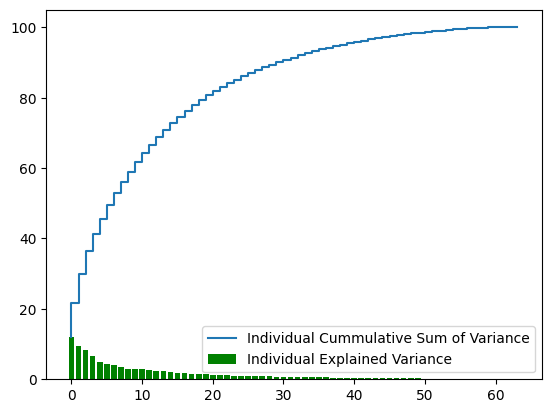

In [33]:
plt.bar(range(len(expl_var)), expl_var, label = 'Individual Explained Variance', color = 'g')
plt.step(range(len(cumsum_var)), cumsum_var, label = 'Individual Cummulative Sum of Variance')
plt.legend()
plt.show()

By seeing the graph I can choose components between 30-35 we can do hit and trail between 30-35 i can get 90-95% of expalined variance by those component  

In order to process the steps , we can use sklearn PCA

In [34]:
from sklearn.decomposition import PCA

In [43]:
pca = PCA(n_components=35) # It selects as many components you want to retrive
# PCA(0.95) you are preserving 95% of data --> n_component --> Automatically
# pca = PCA(0.95)

In [44]:
x_pca = pca.fit_transform(x)
x_pca

array([[ -1.25946645, -21.27488348,   9.46305462, ...,   0.16284181,
         -2.11297739,   1.09482318],
       [  7.9576113 ,  20.76869896,  -4.43950604, ...,  -2.15440692,
          0.16680588,   3.19142836],
       [  6.99192297,   9.95598641,  -2.95855808, ...,   0.34108472,
         -0.50561683,  -2.80824525],
       ...,
       [ 10.8012837 ,   6.96025223,  -5.59955453, ...,   3.21344127,
          0.69773018,   4.05113112],
       [ -4.87210009, -12.42395362,  10.17086635, ...,   0.02313818,
         -0.43310266,   0.57909851],
       [ -0.34438963,  -6.36554919, -10.77370849, ...,   0.8969281 ,
          1.62372487,  -0.47500261]])

In [45]:
x_pca.shape # 35-> Princpal Compenent used to train the model(not 64)

(1797, 35)

In [46]:
pca.n_components

35

Now we build supervised model using the PCA componenet

In [47]:
from sklearn.model_selection import train_test_split

In [50]:
x_train, x_test, y_train, y_test = train_test_split(x_pca, y, test_size = 0.2, random_state = 42)

In [51]:
from sklearn.linear_model import LogisticRegression

In [52]:
model = LogisticRegression()

In [53]:
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [54]:
from sklearn.metrics import accuracy_score

In [56]:
model.score(x_test,y_test)

0.9694444444444444

In [58]:
y_pred = model.predict(x_test)

In [59]:
accuracy_score(y_pred,y_test)

0.9694444444444444

In [60]:
x_test[0] --> 6

array([ 1.52589157e+01, -1.10975014e+01, -1.33231806e+01,  5.22432241e+00,
        1.23108272e+00, -1.54214383e+01,  8.17440554e+00,  3.09484816e+00,
       -1.05120777e+01, -5.13311329e+00,  3.12273750e+00,  4.63460434e+00,
        1.41722655e+00, -2.42359350e+00,  1.30649410e+00, -1.19238530e+00,
       -4.50252340e+00, -3.02686857e+00, -2.98434402e-01, -2.10602260e-01,
        5.52407342e+00, -1.24092771e+00, -4.75377268e-01,  1.42805510e-02,
       -3.61482887e+00,  1.17520179e+00,  6.46226486e-02,  3.19146421e-02,
       -5.83811578e-01,  2.54959218e-02,  1.92794014e+00, -1.78174251e+00,
        7.20878465e-01, -2.43170386e+00,  5.19968472e-02])

In [62]:
output = pca.inverse_transform(x_test[0])

In [63]:
output

array([ 0.00000000e+00,  9.14631164e-02, -7.17857020e-01,  9.44621064e+00,
        1.15252314e+01,  9.24671116e-02,  2.58044897e-01,  2.86560544e-01,
       -5.49253083e-03,  2.25456454e-01,  4.11639696e+00,  1.66116537e+01,
        8.00970153e+00,  1.71877065e-01, -1.21341465e-01,  3.34960255e-01,
       -4.29682271e-04,  2.02947805e-01,  1.20538675e+01,  1.07624794e+01,
       -5.20051057e-01,  3.80311177e-01, -7.72625708e-02,  1.58128198e-01,
        1.70792022e-03,  2.21775479e-01,  1.41995879e+01,  1.08226518e+01,
        7.98821773e+00,  5.45805374e+00,  1.04269914e+00,  7.11713669e-03,
       -3.50926809e-15,  8.63152117e-01,  1.56715539e+01,  1.52692754e+01,
        8.08538356e+00,  1.03111232e+01,  7.03392722e+00,  1.67966182e-15,
       -3.49969792e-02, -1.73046806e-01,  1.29924014e+01,  8.13447432e+00,
       -3.11716718e-02, -2.41880551e-01,  1.35774807e+01,  4.43548751e-01,
       -3.02915722e-03, -6.81164736e-02,  8.70324361e+00,  9.67404841e+00,
        6.45118971e-01,  

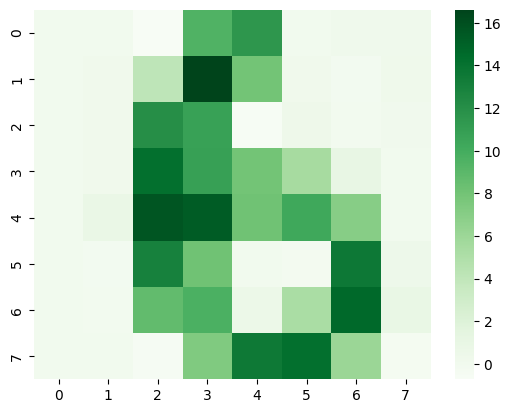

In [65]:
sns.heatmap(output.reshape(8,8),cmap = 'Greens')
plt.show()

Let's try on face data

In [66]:
from sklearn.datasets import fetch_lfw_people

In [67]:
faces = fetch_lfw_people(min_faces_per_person=50, resize = 0.4)
faces

{'data': array([[0.31764707, 0.35555556, 0.45228758, ..., 0.42222223, 0.5921569 ,
         0.49019608],
        [0.1385621 , 0.27320263, 0.33464053, ..., 0.23529412, 0.3267974 ,
         0.45490196],
        [0.33594772, 0.21830066, 0.22745098, ..., 0.6928105 , 0.32156864,
         0.303268  ],
        ...,
        [0.19346406, 0.24705882, 0.34248367, ..., 0.7346406 , 0.6640523 ,
         0.6117647 ],
        [0.530719  , 0.62614375, 0.6653595 , ..., 0.9163399 , 0.8928105 ,
         0.8862745 ],
        [0.11633987, 0.10196079, 0.1267974 , ..., 0.13333334, 0.13725491,
         0.2535948 ]], dtype=float32),
 'images': array([[[0.31764707, 0.35555556, 0.45228758, ..., 0.20522876,
          0.24444444, 0.30588236],
         [0.34640524, 0.3764706 , 0.39869282, ..., 0.18954249,
          0.17777778, 0.27973858],
         [0.36601308, 0.37254903, 0.3254902 , ..., 0.24183007,
          0.17908497, 0.21960784],
         ...,
         [0.19084968, 0.18300654, 0.17908497, ..., 0.7241831 ,
     

In [69]:
faces.keys()

dict_keys(['data', 'images', 'target', 'target_names', 'DESCR'])

In [70]:
x = faces.data
y = faces.target
target_names = faces.target_names

In [71]:
x.shape

(1560, 1850)

In [72]:
y.shape

(1560,)

In [73]:
# standardize the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [77]:
# Applying PCA
pca = PCA(0.95)
x_pca = pca.fit_transform(x_scaled)

In [78]:
x_pca

array([[-3.8312912e+01, -4.6920314e+00, -5.7104297e+00, ...,
         1.0185716e+00,  1.5859535e+00,  6.1290759e-01],
       [-2.3785633e+01,  1.4437968e+01,  2.7663898e-02, ...,
         1.4611685e-01,  5.4893490e-02, -8.1556141e-01],
       [ 1.8416572e+00,  3.1604454e+01, -8.8701159e-01, ...,
         7.6975030e-01, -7.5123680e-01,  1.1042470e+00],
       ...,
       [ 2.6434017e+01,  9.9793777e+00, -1.3774900e+01, ...,
        -8.6787963e-01,  1.5544653e-01,  2.8869715e-01],
       [ 3.2614483e+01, -3.0664558e+00, -1.1733527e+00, ...,
         3.6532769e-01,  1.7593135e+00, -6.9625387e-03],
       [-7.0555015e+00,  3.5971618e+00, -8.0185165e+00, ...,
         2.0121775e+00,  6.7610964e-02, -1.6938753e-01]], dtype=float32)

In [76]:
x_scaled.shape

(1560, 1850)

In [79]:
x_pca.shape

(1560, 172)

95% of varaince we are retaining by selecting 172 components

In [80]:
pca.explained_variance_ratio_

array([0.29187968, 0.13005379, 0.06682254, 0.04842016, 0.02989636,
       0.02382712, 0.01848551, 0.01577829, 0.01467483, 0.01458596,
       0.01214623, 0.01165982, 0.01130418, 0.00965939, 0.00920598,
       0.00870777, 0.00836819, 0.00734768, 0.00627831, 0.00625898,
       0.00581151, 0.00533258, 0.00506566, 0.00498504, 0.00468353,
       0.00445789, 0.00412111, 0.00397588, 0.00395292, 0.00362334,
       0.00355512, 0.00343419, 0.00334578, 0.00324061, 0.00308968,
       0.00300267, 0.00293456, 0.00281127, 0.00275103, 0.00263272,
       0.00254971, 0.00253125, 0.00246606, 0.00241842, 0.00229548,
       0.00225308, 0.00224113, 0.00216677, 0.00213999, 0.00209389,
       0.00201583, 0.00198641, 0.00193044, 0.00187159, 0.00182554,
       0.00180644, 0.00178916, 0.00176266, 0.00170338, 0.00165781,
       0.00161333, 0.0015936 , 0.00154309, 0.00150032, 0.00147589,
       0.00146045, 0.00143517, 0.00141507, 0.00137925, 0.00135413,
       0.00134373, 0.00131298, 0.00128039, 0.00126286, 0.00125

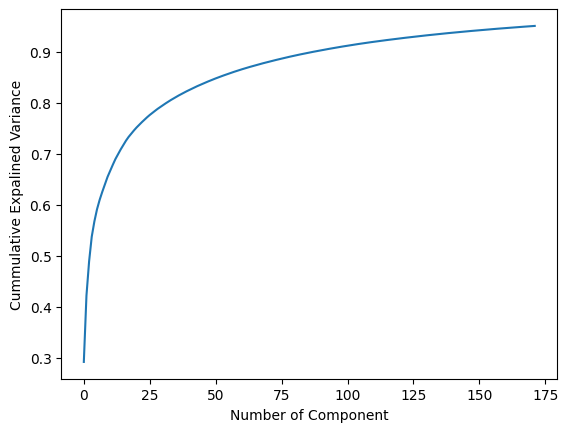

In [81]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Component")
plt.ylabel("Cummulative Expalined Variance")
plt.show()

This Graph shows how much variance is expalined as we increased the component

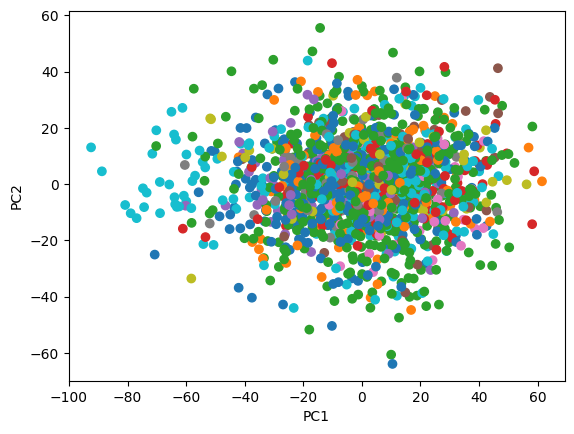

In [82]:
plt.scatter(x_pca[:,0],x_pca[:,1],c=y,cmap='tab10')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Try to plot this eigen faces

In [84]:
eigenfaces = pca.components_.reshape(
    pca.n_components_, faces.images.shape[1], faces.images.shape[2]
)
eigenfaces

array([[[ 6.13516569e-03,  7.83705711e-03,  1.06109567e-02, ...,
          9.84245725e-03,  8.83923564e-03,  8.00610613e-03],
        [ 7.48966541e-03,  9.56298131e-03,  1.22697651e-02, ...,
          1.10939350e-02,  9.65734385e-03,  9.05892253e-03],
        [ 9.08790901e-03,  1.13109881e-02,  1.37929628e-02, ...,
          1.29278619e-02,  1.06837498e-02,  9.71670449e-03],
        ...,
        [ 3.02433595e-03,  3.25930677e-03,  4.36131051e-03, ...,
          6.27990346e-03,  5.28612174e-03,  4.51977830e-03],
        [ 2.79499753e-03,  3.31381639e-03,  4.07388154e-03, ...,
          5.98498899e-03,  5.21493377e-03,  4.40342445e-03],
        [ 2.90219649e-03,  3.37536540e-03,  4.13938146e-03, ...,
          5.84760448e-03,  5.27709816e-03,  4.36802302e-03]],

       [[-1.68472603e-02, -1.67013891e-02, -1.90828443e-02, ...,
          1.73004437e-02,  1.69655345e-02,  1.68346073e-02],
        [-1.76245812e-02, -1.82646643e-02, -2.18817648e-02, ...,
          1.84447709e-02,  1.81886666e

In [86]:
eigenfaces.shape

(172, 50, 37)

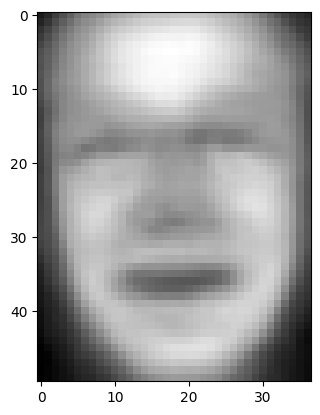

In [88]:
plt.imshow(eigenfaces[0],cmap = 'gray')
plt.show()

In [90]:
x_reconstruct = pca.inverse_transform(x_pca)

In [94]:
x_reconstruct = scaler.inverse_transform(x_reconstruct)

# 2 times we done inverse transfromation same pca model to get back best possible image quality

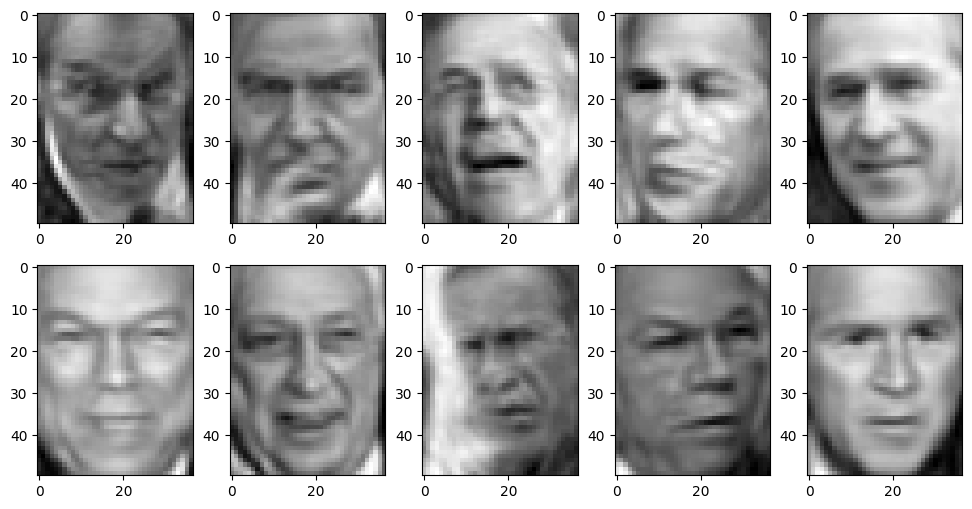

In [98]:
fig, axes = plt.subplots(2,5, figsize = (12,6))
for i,ax in enumerate(axes.flat):
  ax.imshow(x_reconstruct[i].reshape(faces.images[0].shape), cmap = 'gray')

plt.show()